# 1 Problem Definition

### Task: Suspicious Transaction Detection (AML)

Financial institutions process thousands of transactions daily, making it difficult to manually identify suspicious or fraudulent activities. Illegal financial activities such as money laundering and fraudulent transactions pose serious security and financial risks.

This project aims to develop a Machine Learning system that can automatically detect suspicious transactions by identifying unusual transaction behaviors and patterns.

**Goal**

The goal of this project is to detect anomalous or suspicious transactions using unsupervised machine learning algorithms.

**Problem Type**
Unsupervised Learning
Anomaly Detection
Success Criteria

The project is considered successful if the model can effectively identify suspicious transactions with good anomaly detection performance.

### Data Collection
The dataset used in this project contains financial transaction records.

Data Source

The dataset was collected from local and anonymized CSV transaction files containing transaction-related information

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Data Collection
transactions_df = pd.read_csv('/content/Trx_ML.csv')

print("Transactions Data Shape:", transactions_df.shape)

Transactions Data Shape: (1048575, 8)


We load the new transactions dataset (`Trx_ML.csv`) using `pandas`.The dataset was loaded using the Pandas library and stored in the variable transactions_df.

The shape of the dataset was checked to determine:

- Number of rows

- Number of columns

 Initial inspection of data shape is performed to confirm successful loading.

We will preprocess the data by extracting time-based features from 'CreatedOn' and scaling numerical features, which is crucial for distance-based and isolation-based anomaly detection algorithms.

### Data Preparation & Preprocessing

Learning algorithms.
The preprocessing step helps improve data quality, handle inconsistencies, and transform the dataset into a format suitable for clustering algorithms such as K-Means and DBSCAN.

Preprocessing Activities Performed

**1.Date and Time Feature Extraction**

The CreatedOn column was converted into datetime format to extract useful transaction time information.

A new feature called CreatedOn_hour was created to represent the transaction hour.

2.**Removing Unnecessary Columns**

Cheque-related columns that were not required for anomaly detection were removed from the dataset.

**3. Feature Selection**

The following features were selected for anomaly detection:

**Numerical Features**
- LocalAmount
- CreatedOn_hour

**Categorical Features**

- Anon_AccountId
- TransactionChannels

**4. Handling Missing Values**

Rows with missing numerical values were removed.
Missing categorical values were replaced with "Unknown".

**5. Feature Encoding and Scaling**

To prepare the dataset for machine learning algorithms:

Numerical features were standardized using StandardScaler.
Categorical features were transformed using OneHotEncoder.

**6. Data Transformation**

A ColumnTransformer pipeline was used to apply preprocessing operations efficiently to both numerical and categorical features.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd # Ensure pandas is imported as it's needed for DataFrame operations

# 4. Data Preparation & Preprocessing for Anomaly Detection

# Ensure 'CreatedOn' is a datetime object
transactions_df['CreatedOn_dt'] = pd.to_datetime(transactions_df['CreatedOn'], errors='coerce')
transactions_df['CreatedOn_hour'] = transactions_df['CreatedOn_dt'].dt.hour

# Explicitly drop ChequeDate related columns if they exist in the DataFrame
cols_to_drop_if_exist = ['ChequeDate_dt', 'ChequeDate_dayofweek', 'ChequeDate'] # Added 'ChequeDate' itself
for col in cols_to_drop_if_exist:
    if col in transactions_df.columns:
        transactions_df.drop(columns=[col], inplace=True)
        print(f"Dropped column: {col}")

# Define numerical and categorical features for anomaly detection
numerical_features = ['LocalAmount', 'CreatedOn_hour']
categorical_features = ['Anon_AccountId', 'TransactionChannels']

# Drop rows where critical numerical features are NaN
transactions_df.dropna(subset=numerical_features, inplace=True)

# Handle potential missing values in categorical columns if any, e.g., fill with 'Unknown'
for col in categorical_features:
    if col in transactions_df.columns:
        transactions_df[col] = transactions_df[col].fillna('Unknown')
    else:
        print(f"Warning: Column '{col}' not found in transactions_df. Skipping categorical feature handling for it.")
        # If a categorical feature is completely missing, it won't be part of the final X_scaled_unsupervised

# Create a preprocessor using ColumnTransformer for one-hot encoding and scaling
# This handles different transformations for different column types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # handle_unknown='ignore' to deal with categories not seen during fit
    ],
    remainder='drop' # Drop columns not specified in transformers
)

# Fit and transform the data
X_scaled_unsupervised = preprocessor.fit_transform(transactions_df)

# For reference, redefine features_for_anomaly to reflect what's being processed
# The actual column names for the one-hot encoded features will be generated by the preprocessor
features_for_anomaly = numerical_features + categorical_features

print("Data successfully prepared and scaled for unsupervised anomaly detection (Anon_AccountId and TransactionChannels added).")


Dropped column: ChequeDate
Data successfully prepared and scaled for unsupervised anomaly detection (Anon_AccountId and TransactionChannels added).


### Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) was performed to better understand the transaction dataset, analyze feature distributions, identify unusual patterns, and detect potential anomalies related to suspicious transactions.

The analysis focused on important transaction features such as transaction amount, transaction time, and transaction channels.

Objectives of EDA

The main objectives of the EDA process were to:

- Understand the structure of the dataset
- Analyze the distribution of transaction values
- Identify potential outliers and anomalies
- Discover hidden patterns and trends
- Visualize transaction behavior
Prepare the dataset for anomaly detection algorithm

In [ ]:
# Initial EDA for the new transactions data
print("Transactions_df Info:")
transactions_df.info()

print("\nTransactions_df Description:")
display(transactions_df.describe())

Transactions_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   Anon_AccountId       1048575 non-null  object        
 1   Cheque               1048575 non-null  object        
 2   TrxTypeID            1048575 non-null  object        
 3   LocalAmount          1048575 non-null  float64       
 4   TrxType              1048575 non-null  object        
 5   CreatedOn            1048575 non-null  object        
 6   TransactionChannels  1048575 non-null  object        
 7   CreatedOn_dt         1048575 non-null  datetime64[ns]
 8   CreatedOn_hour       1048575 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(6)
memory usage: 68.0+ MB

Transactions_df Description:


,LocalAmount,CreatedOn_dt,CreatedOn_hour
count,1.048575e+06,1048575,1.048575e+06
mean,-3.448817e+02,2025-05-17 08:11:33.365566464,1.316894e+01
min,-1.000000e+08,2020-12-29 14:09:00,0.000000e+00
25%,-2.000000e+03,2025-02-07 09:30:00,1.000000e+01
50%,-2.000000e+02,2025-07-31 08:07:00,1.300000e+01
75%,1.428000e+03,2025-11-20 16:15:00,1.600000e+01
max,6.286744e+07,2026-03-01 16:20:00,2.300000e+01
std,3.716065e+05,NaN,3.372552e+00


info() was used to inspect:
- Number of rows and columns
- Data types
- Missing values

describe() was used to generate statistical summaries such as:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

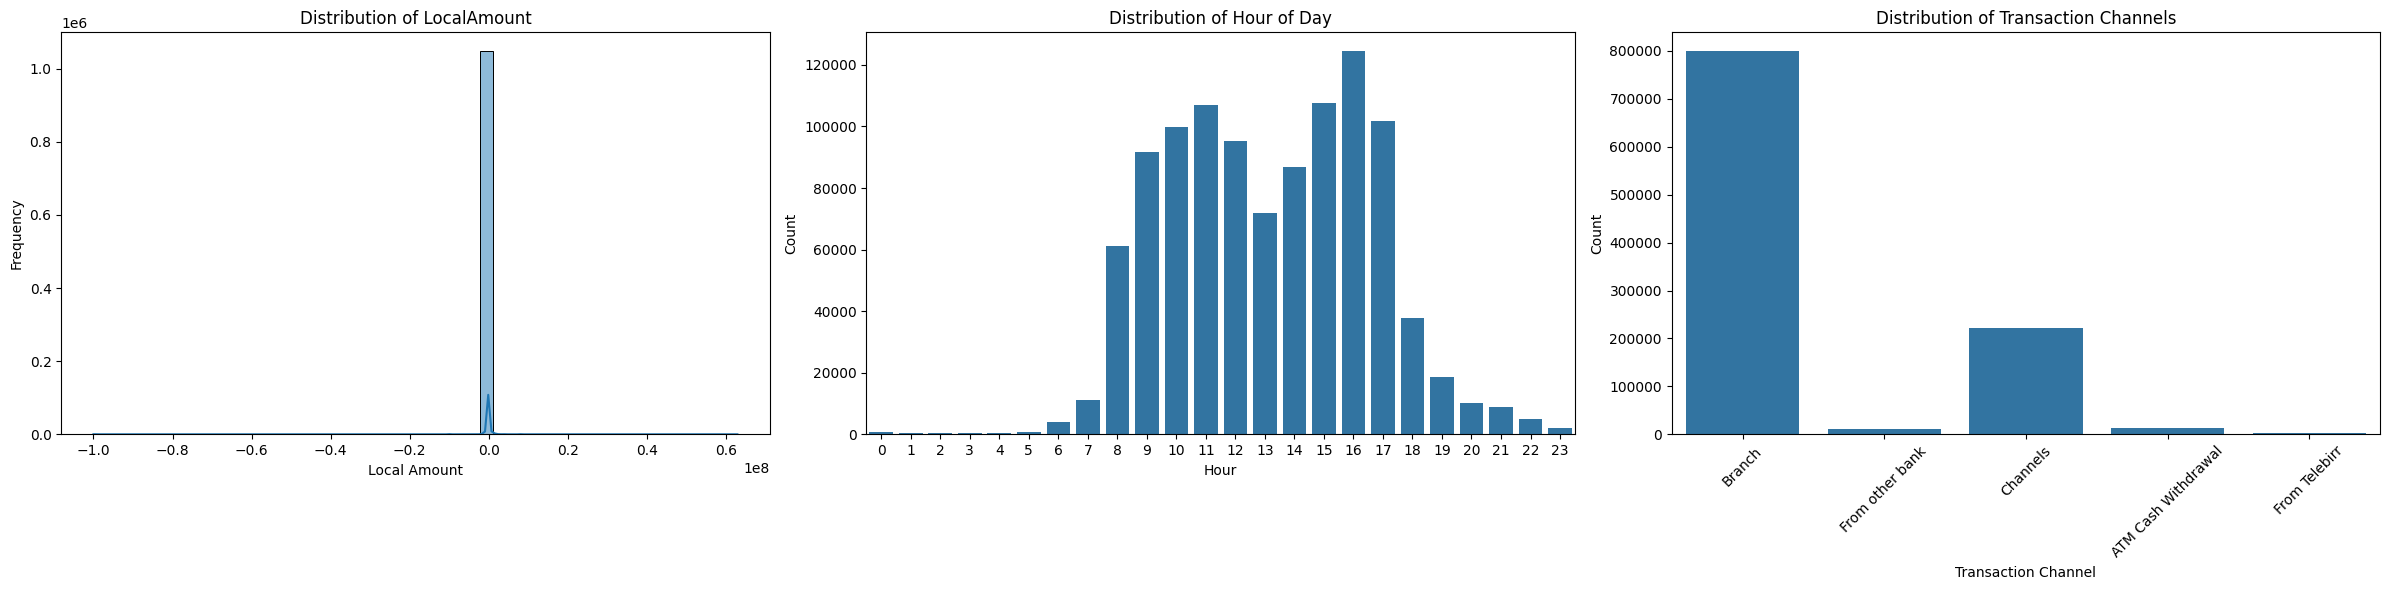

In [ ]:
# 3. Exploratory Data Analysis (EDA)
# Adjusting subplot layout as TransactionChannels is added
fig, ax = plt.subplots(1, 3, figsize=(24, 6)) # Increased number of subplots to 3

# Distribution of LocalAmount
sns.histplot(transactions_df['LocalAmount'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Distribution of LocalAmount')
ax[0].set_xlabel('Local Amount')
ax[0].set_ylabel('Frequency')

# Distribution of CreatedOn_hour
sns.countplot(x='CreatedOn_hour', data=transactions_df, ax=ax[1])
ax[1].set_title('Distribution of Hour of Day')
ax[1].set_xlabel('Hour')
ax[1].set_ylabel('Count')

# Distribution of TransactionChannels (New plot)
if 'TransactionChannels' in transactions_df.columns:
    sns.countplot(x='TransactionChannels', data=transactions_df, ax=ax[2])
    ax[2].set_title('Distribution of Transaction Channels')
    ax[2].set_xlabel('Transaction Channel')
    ax[2].set_ylabel('Count')
    ax[2].tick_params(axis='x', rotation=45) # Rotate labels if they overlap
else:
    fig.delaxes(ax[2]) # Remove empty subplot if column is missing
    print("Warning: 'TransactionChannels' column not found for plotting.")

plt.tight_layout()
plt.show()

Visualization techniques were used to explore important features in the dataset.

The following plots were generated:

- Distribution of transaction amounts (LocalAmount)
- Distribution of transaction hours (CreatedOn_hour)
- Distribution of transaction channels (TransactionChannels)

### Model Development & Parameter Selection (Unsupervised)
We will develop and apply various unsupervised anomaly detection models:
-   **DBSCAN**: A density-based clustering algorithm where anomalies are identified as noise points (not belonging to any cluster).
-   **K-Means**: A clustering method where anomalies are identified as data points far from their assigned cluster centroids.

For each model, key parameters (`eps`, `min_samples`, `n_clusters`, anomaly `threshold`) will be chosen, which often requires domain knowledge and iterative experimentation.

### Explanation of Unsupervised Anomaly Detection Results

Each unsupervised model will output a set of 'anomalies' or 'suspicious' transactions based on its underlying principles:
*   **DBSCAN**: Classifies points that are not part of any dense cluster as noise/anomalies.
*   **K-Means**: Identifies anomalies as data points that are far from their assigned cluster centroids.

The interpretation will focus on the number of detected anomalies and their characteristics. Further analysis would involve domain expert review of these flagged transactions.

### Model Evaluation (Unsupervised)
We will evaluate the performance of each unsupervised anomaly detection model. For unsupervised models, evaluation is often more qualitative, relying on:
-   The number of detected anomalies.
-   Visualizations of anomaly scores or clusters.
-   Future validation with domain experts.

The exploratory analysis revealed several important observations:

- Transaction amounts showed variation with some extreme values indicating possible anomalies.
- Certain hours of the day contained higher transaction frequencies.
- Some transaction channels were used more frequently than others.
- Potential outliers were identified in transaction amount distributions.

These findings helped guide preprocessing and anomaly detection model selection.

### Model Deployment (Anomaly Detection)

In [ ]:
import pickle
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Ensure these are imported if not already in the cell
from sklearn.compose import ColumnTransformer # Ensure this is imported

# Save the Isolation Forest model

# Ensure 'iso_forest', 'preprocessor', 'numerical_features', and 'categorical_features' are available from earlier execution
try:
    with open('isolation_forest_model.pkl', 'wb') as f:
        pickle.dump({
            'model': iso_forest,
            'preprocessor': preprocessor,
            'numerical_features': numerical_features,
            'categorical_features': categorical_features
        }, f)
    print("Isolation Forest model, preprocessor, and feature names saved successfully to 'isolation_forest_model.pkl'!")
except NameError as e:
    print(f"Error: {e}. Isolation Forest model, preprocessor or feature lists not found. Please ensure the Isolation Forest cell and preprocessing steps were run.")

Isolation Forest model, preprocessor, and feature names saved successfully to 'isolation_forest_model.pkl'!


In [ ]:
import pickle

# Save the best performing unsupervised anomaly detection model (e.g., Isolation Forest, or K-Means, etc.)
# You can choose which model to save by uncommenting the appropriate line.

# Ensure 'preprocessor', 'numerical_features', and 'categorical_features' are available from earlier execution
try:
    # Define the model you wish to save. For example, if Isolation Forest performed best:
    # selected_model = iso_forest
    # model_name = 'Isolation Forest'

    # If K-Means performed best:
    selected_model = kmeans_model
    model_name = 'K-Means'

    # If DBSCAN performed best:
    # selected_model = dbscan_model
    # model_name = 'DBSCAN'

    with open('anomaly_detection_model.pkl', 'wb') as f:
        pickle.dump(
            {
                'model': selected_model,
                'preprocessor': preprocessor,
                'numerical_features': numerical_features,
                'categorical_features': categorical_features,
            }, f
        )
    print(f"Anomaly detection model ({model_name}), preprocessor, and feature names saved successfully!")
except NameError as e:
    print(
        f"Error: {e}. One of the required variables (model, preprocessor, or feature lists) not found. Please ensure the relevant model cell and preprocessing steps were run."
    )
except Exception as e:
    print(f"An unexpected error occurred during model saving: {e}")

Anomaly detection model (K-Means), preprocessor, and feature names saved successfully!


In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Ensure these are imported for compatibility with ColumnTransformer
from sklearn.compose import ColumnTransformer

st.set_page_config(page_title="ML Assignment Deployment", layout="wide")
st.title("🚀 Anomaly Detection Deployment")

st.header("Suspicious Transaction Detection")
st.write("Enter transaction details below or upload a CSV file for anomaly detection.")

# Function to load model and preprocessor
@st.cache_resource
def load_anomaly_bundle():
    try:
        with open('anomaly_detection_model.pkl', 'rb') as f:
            bundle = pickle.load(f)
        return bundle['model'], bundle['preprocessor'], bundle['numerical_features'], bundle['categorical_features']
    except FileNotFoundError:
        st.error("Anomaly detection model bundle not found. Please train and save the model first.")
        return None, None, None, None

anomaly_model, preprocessor, numerical_features_saved, categorical_features_saved = load_anomaly_bundle()

if anomaly_model and preprocessor and numerical_features_saved is not None and categorical_features_saved is not None:
    # Option 1: Individual Transaction Input
    st.subheader("Single Transaction Anomaly Prediction")

    # Create input fields for numerical features
    input_values_num = {}
    cols_num = st.columns(len(numerical_features_saved))
    for i, feature in enumerate(numerical_features_saved):
        with cols_num[i]:
            default_value = 0.0
            if feature == 'LocalAmount':
                default_value = 100.0
            elif 'hour' in feature:
                default_value = 12 # Midday
            input_values_num[feature] = st.number_input(f"{feature} (Numerical)", value=default_value, format="%.2f", key=f"single_{feature}_num")

    # Create input fields for categorical features
    input_values_cat = {}
    cols_cat = st.columns(len(categorical_features_saved))
    for i, feature in enumerate(categorical_features_saved):
        with cols_cat[i]:
            # For categorical features, allow text input or select from common values if known
            if feature == 'TransactionChannels':
                common_channels = ['Online', 'Branch', 'ATM', 'Mobile'] # Example common channels
                input_values_cat[feature] = st.selectbox(f"{feature} (Categorical)", options=common_channels, key=f"single_{feature}_cat")
            else:
                input_values_cat[feature] = st.text_input(f"{feature} (Categorical)", value=f"test_id_example", key=f"single_{feature}_cat") # Example default for Anon_AccountId

    if st.button("Detect Anomaly in Single Transaction"): # Changed button text
        if anomaly_model and preprocessor:
            # Combine all input values into a DataFrame row for preprocessing
            single_transaction_data = pd.DataFrame([{**input_values_num, **input_values_cat}])

            # Ensure all required original features are present in the DataFrame for preprocessor
            required_columns = numerical_features_saved + categorical_features_saved
            for col in required_columns:
                if col not in single_transaction_data.columns:
                    st.error(f"Missing input for required feature: {col}")
                    st.stop()

            # Apply the preprocessor
            scaled_single = preprocessor.transform(single_transaction_data[required_columns])
            pred_single = anomaly_model.predict(scaled_single)

            if pred_single[0] == -1: # Isolation Forest predicts -1 for anomalies
                st.error("⚠️ Suspicious Transaction Detected!")
            else:
                st.success("✅ Normal Transaction.")

    st.markdown("--- ")

    # Option 2: CSV File Upload
    st.subheader("Batch Anomaly Detection from CSV")
    uploaded_file = st.file_uploader("Upload a CSV file for anomaly detection", type=["csv"])

    if uploaded_file is not None:
        df_uploaded = pd.read_csv(uploaded_file)
        st.write("Uploaded Data Preview:", df_uploaded.head())

        # --- Preprocessing for uploaded CSV (mirroring notebook) ---
        # Ensure 'CreatedOn_dt' and 'CreatedOn_hour' are generated if 'CreatedOn' exists and is needed
        if 'CreatedOn' in df_uploaded.columns and 'CreatedOn_hour' in numerical_features_saved:
            df_uploaded['CreatedOn_dt'] = pd.to_datetime(df_uploaded['CreatedOn'], errors='coerce')
            df_uploaded['CreatedOn_hour'] = df_uploaded['CreatedOn_dt'].dt.hour
        elif 'CreatedOn_hour' in numerical_features_saved and 'CreatedOn_hour' not in df_uploaded.columns:
            st.warning("Column 'CreatedOn' not found in uploaded CSV, and 'CreatedOn_hour' is a required numerical feature. Filling 'CreatedOn_hour' with 0 (default).")
            df_uploaded['CreatedOn_hour'] = 0 # Default value if not present

        # Drop rows where numerical features are NaN (important for preprocessor)
        df_uploaded.dropna(subset=[f for f in numerical_features_saved if f in df_uploaded.columns], inplace=True)

        # Handle missing categorical values in uploaded data
        for col in categorical_features_saved:
            if col not in df_uploaded.columns:
                st.warning(f"Column '{col}' not found in uploaded CSV. Adding column and filling with 'Unknown'.")
                df_uploaded[col] = 'Unknown'
            else:
                df_uploaded[col] = df_uploaded[col].fillna('Unknown') # Fill NaNs if column exists

        # Ensure all required columns are present for the preprocessor
        all_required_cols = numerical_features_saved + categorical_features_saved
        missing_from_uploaded = [col for col in all_required_cols if col not in df_uploaded.columns]
        if missing_from_uploaded:
            st.error(f"Error: Uploaded CSV and its processed form must contain all required features: {', '.join(all_required_cols)}. Missing: {', '.join(missing_from_uploaded)}")
            st.stop()

        X_uploaded = df_uploaded[all_required_cols]

        # Apply the preprocessor
        scaled_uploaded = preprocessor.transform(X_uploaded)
        predictions = anomaly_model.predict(scaled_uploaded)

        df_uploaded['Anomaly_Prediction'] = np.where(predictions == -1, "Suspicious", "Normal")

        st.write("Anomaly Detection Results:")
        st.dataframe(df_uploaded.style.apply(lambda x: ["background-color: #ffe6e6" if x["Anomaly_Prediction"] == "Suspicious" else "" for i in x], axis=1))

        num_suspicious = (df_uploaded["Anomaly_Prediction"] == "Suspicious").sum()
        st.info(f"Detected {num_suspicious} suspicious transactions out of {len(df_uploaded)} processed records.")
else:
    st.warning("Model could not be loaded. Please ensure the anomaly detection model is trained and saved in the notebook.")


Writing app.py


In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans # Import KMeans for potentially deployed model
from sklearn.ensemble import IsolationForest # Import IsolationForest
from sklearn.cluster import DBSCAN # Import DBSCAN

st.set_page_config(page_title="ML Assignment Deployment", layout="wide")
st.title("🚀 Anomaly Detection Deployment")

st.header("Suspicious Transaction Detection")
st.write("Enter transaction details below or upload a CSV file for anomaly detection.")

# Function to load model and preprocessor based on selection
@st.cache_resource
def load_anomaly_bundle(selected_model_name):
    model_filename = ''
    if selected_model_name == 'DBSCAN':
        model_filename = 'dbscan_model.pkl'
    elif selected_model_name == 'K-Means':
        model_filename = 'kmeans_model.pkl'

    if not model_filename:
        st.error("No model selected or model filename not defined.")
        return None, None, None, None, None # Added threshold as last None

    try:
        with open(model_filename, 'rb') as f:
            bundle = pickle.load(f)
        model = bundle['model']
        preprocessor = bundle['preprocessor']
        numerical_features = bundle['numerical_features']
        categorical_features = bundle['categorical_features']
        threshold = bundle.get('threshold') # K-Means specific
        return model, preprocessor, numerical_features, categorical_features, threshold
    except FileNotFoundError:
        st.error(f"Anomaly detection model bundle '{model_filename}' not found. Please train and save the model first.")
        return None, None, None, None, None

# Model selection dropdown
selected_model_option = st.selectbox(
    "Choose an Anomaly Detection Model:",
    ('DBSCAN', 'K-Means'),
    index=0 # DBSCAN
)

anomaly_model, preprocessor, numerical_features_saved, categorical_features_saved, kmeans_threshold = load_anomaly_bundle(selected_model_option)

if anomaly_model and preprocessor and numerical_features_saved is not None and categorical_features_saved is not None:
    # Determine the type of the loaded model for specific prediction logic if needed
    model_type = type(anomaly_model).__name__

    # Option 1: Individual Transaction Input
    st.subheader("Single Transaction Anomaly Prediction")

    # Create input fields for numerical features
    input_values_num = {}
    cols_num = st.columns(len(numerical_features_saved))
    for i, feature in enumerate(numerical_features_saved):
        with cols_num[i]:
            default_value = 0.0
            if feature == 'LocalAmount':
                default_value = 100.0
            elif 'hour' in feature:
                default_value = 12 # Midday
            input_values_num[feature] = st.number_input(f"{feature} (Numerical)", value=default_value, format="%.2f", key=f"single_{feature}_num")

    # Create input fields for categorical features
    input_values_cat = {}
    cols_cat = st.columns(len(categorical_features_saved))
    for i, feature in enumerate(categorical_features_saved):
        with cols_cat[i]:
            if feature == 'TransactionChannels':
                common_channels = ['Online', 'Branch', 'ATM', 'Mobile', 'Unknown'] # Example common channels, include 'Unknown'
                input_values_cat[feature] = st.selectbox(f"{feature} (Categorical)", options=common_channels, key=f"single_{feature}_cat")
            else:
                input_values_cat[feature] = st.text_input(f"{feature} (Categorical)", value=f"test_id_example", key=f"single_{feature}_cat")

    if st.button("Detect Anomaly in Single Transaction"): # Changed button text
        if anomaly_model and preprocessor:
            single_transaction_data = pd.DataFrame([{**input_values_num, **input_values_cat}])

            required_columns = numerical_features_saved + categorical_features_saved
            for col in required_columns:
                if col not in single_transaction_data.columns:
                    st.error(f"Missing input for required feature: {col}")
                    st.stop()

            scaled_single = preprocessor.transform(single_transaction_data[required_columns])

            # Adjust prediction logic based on model type
            if model_type == 'KMeans':
                distances = anomaly_model.transform(scaled_single)
                min_distance = np.min(distances, axis=1)[0]
                if kmeans_threshold is not None:
                    st.write(f"Distance to nearest centroid: {min_distance:.2f} (Threshold: {kmeans_threshold:.2f})")
                    if min_distance > kmeans_threshold:
                         st.error("⚠️ Suspicious Transaction Detected! (K-Means distance based)")
                    else:
                         st.success("✅ Normal Transaction. (K-Means distance based)")
                else:
                    st.warning("K-Means threshold not loaded. Cannot reliably classify anomaly.")

            elif model_type == 'DBSCAN':
                # DBSCAN predict returns cluster labels (-1 for anomalies)
                pred_single = anomaly_model.fit_predict(scaled_single)
                if pred_single[0] == -1:
                    st.error("⚠️ Suspicious Transaction Detected! (DBSCAN)")
                else:
                    st.success("✅ Normal Transaction. (DBSCAN)")

    st.markdown("--- ")

    # Option 2: CSV File Upload
    st.subheader("Batch Anomaly Detection from CSV")
    uploaded_file = st.file_uploader("Upload a CSV file for anomaly detection", type=["csv"])

    if uploaded_file is not None:
        df_uploaded = pd.read_csv(uploaded_file)
        st.write("Uploaded Data Preview:", df_uploaded.head())

        if 'CreatedOn' in df_uploaded.columns and 'CreatedOn_hour' in numerical_features_saved:
            df_uploaded['CreatedOn_dt'] = pd.to_datetime(df_uploaded['CreatedOn'], errors='coerce')
            df_uploaded['CreatedOn_hour'] = df_uploaded['CreatedOn_dt'].dt.hour
        elif 'CreatedOn_hour' in numerical_features_saved and 'CreatedOn_hour' not in df_uploaded.columns:
            st.warning("Column 'CreatedOn' not found in uploaded CSV, and 'CreatedOn_hour' is a required numerical feature. Filling 'CreatedOn_hour' with 0 (default).")
            df_uploaded['CreatedOn_hour'] = 0

        df_uploaded.dropna(subset=[f for f in numerical_features_saved if f in df_uploaded.columns], inplace=True)

        for col in categorical_features_saved:
            if col not in df_uploaded.columns:
                st.warning(f"Column '{col}' not found in uploaded CSV. Adding column and filling with 'Unknown'.")
                df_uploaded[col] = 'Unknown'
            else:
                df_uploaded[col] = df_uploaded[col].fillna('Unknown')

        all_required_cols = numerical_features_saved + categorical_features_saved
        missing_from_uploaded = [col for col in all_required_cols if col not in df_uploaded.columns]
        if missing_from_uploaded:
            st.error(f"Error: Uploaded CSV and its processed form must contain all required features: {', '.join(all_required_cols)}. Missing: {', '.join(missing_from_uploaded)}")
            st.stop()

        X_uploaded = df_uploaded[all_required_cols]

        scaled_uploaded = preprocessor.transform(X_uploaded)

        # Adjust prediction logic based on model type for batch prediction
        if model_type == 'KMeans':
            distances_batch = anomaly_model.transform(scaled_uploaded)
            min_distances_batch = np.min(distances_batch, axis=1)
            if kmeans_threshold is not None:
                predictions_batch = np.where(min_distances_batch > kmeans_threshold, -1, 1)
            else:
                st.warning("K-Means threshold not loaded. Cannot reliably classify anomalies in batch. Defaulting to normal.")
                predictions_batch = np.ones(len(df_uploaded)) # Default to normal if no threshold
        elif model_type == 'DBSCAN':
            predictions_batch = anomaly_model.fit_predict(scaled_uploaded)
        else:
            predictions_batch = anomaly_model.predict(scaled_uploaded)

        df_uploaded['Anomaly_Prediction'] = np.where(predictions_batch == -1, "Suspicious", "Normal")

        st.write("Anomaly Detection Results:")
        st.dataframe(df_uploaded.style.apply(lambda x: ["background-color: #ffe6e6" if x["Anomaly_Prediction"] == "Suspicious" else "" for i in x], axis=1))

        num_suspicious = (df_uploaded["Anomaly_Prediction"] == "Suspicious").sum()
        st.info(f"Detected {num_suspicious} suspicious transactions out of {len(df_uploaded)} processed records.")
else:
    st.warning("Model could not be loaded. Please ensure the anomaly detection model is trained and saved in the notebook."a)

Overwriting app.py


In [ ]:
# Read and display the content of app.py to verify the update
with open('app.py', 'r') as f:
    print(f.read())

import streamlit as st
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Ensure these are imported for compatibility with ColumnTransformer
from sklearn.compose import ColumnTransformer

st.set_page_config(page_title="ML Assignment Deployment", layout="wide")
st.title("🚀 Anomaly Detection Deployment")

st.header("Suspicious Transaction Detection")
st.write("Enter transaction details below or upload a CSV file for anomaly detection.")

# Function to load model and preprocessor
@st.cache_resource
def load_anomaly_bundle():
    try:
        with open('anomaly_detection_model.pkl', 'rb') as f:
            bundle = pickle.load(f)
        return bundle['model'], bundle['preprocessor'], bundle['numerical_features'], bundle['categorical_features']
    except FileNotFoundError:
        st.error("Anomaly detection model bundle not found. Please train and save the model first.")
        return None, None, None, None

anomaly_mod

### Another Unsupervised Anomaly Detection: DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that can also be effectively used for anomaly detection. It groups together data points that are closely packed together, marking as outliers (or 'noise' points) those points that lie alone in low-density regions. Anomalies are typically those points not assigned to any cluster.

In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd

# Ensure 'X_scaled_unsupervised' and 'preprocessor' are available from the preprocessing cell
if 'X_scaled_unsupervised' not in locals() and 'X_scaled_unsupervised' not in globals() or \
   'preprocessor' not in locals() and 'preprocessor' not in globals():
    print("Error: 'X_scaled_unsupervised' or 'preprocessor' not defined. Please run the data preprocessing cell (prep_regression) first.")
else:
    print("Applying DBSCAN for Anomaly Detection on the last 100,000 rows...")

    # Select the last 300,000 rows of the original transactions_df
    transactions_df_subset = transactions_df.tail(100000).copy().reset_index(drop=True)

    # Preprocess the subset using the already fitted preprocessor
    # Ensure all required columns are present in the subset for transformation
    required_cols_subset = numerical_features + [col for col in categorical_features if col in transactions_df_subset.columns]
    X_scaled_unsupervised_subset = preprocessor.transform(transactions_df_subset[required_cols_subset])

    # --- DBSCAN Model Training and Prediction ---
    # DBSCAN parameters:
    # eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    # min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
    # Tuning eps and min_samples is crucial for DBSCAN. Default values might not be optimal.
    # For initial exploration, we'll pick some reasonable values. You might need to adjust these.
    # A common approach for selecting `eps` is to use a k-distance graph (e.g., k=min_samples) to find the 'elbow' point.
    dbscan_model = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1) # Illustrative values, needs tuning for optimal performance

    # Fit the model and predict clusters (-1 indicates noise/anomaly)
    clusters_dbscan = dbscan_model.fit_predict(X_scaled_unsupervised_subset)

    # Add predictions to the subset DataFrame for display
    transactions_df_subset['DBSCAN_Cluster'] = clusters_dbscan

    # Points assigned to cluster -1 are considered anomalies by DBSCAN
    transactions_df_subset['Is_Anomaly_DBSCAN'] = transactions_df_subset['DBSCAN_Cluster'].apply(lambda x: -1 if x == -1 else 1)

    # Map predictions to labels for readability
    transactions_df_subset['Anomaly_Label_DBSCAN'] = transactions_df_subset['Is_Anomaly_DBSCAN'].map({-1: 'Suspicious', 1: 'Normal'})

    print("\nTransactions (last 100,000) with DBSCAN Cluster Assignments and Anomaly Labels:")
    display(transactions_df_subset.head())

    suspicious_transactions_dbscan = transactions_df_subset[transactions_df_subset['Is_Anomaly_DBSCAN'] == -1]
    print(f"\nNumber of detected suspicious transactions by DBSCAN: {len(suspicious_transactions_dbscan)}")
    print("\nDetails of Suspicious Transactions (DBSCAN) from subset:")
    display(suspicious_transactions_dbscan)

    print("\nDBSCAN Cluster Distribution for subset:")
    print(transactions_df_subset['DBSCAN_Cluster'].value_counts())

Applying DBSCAN for Anomaly Detection on the last 300,000 rows...

Transactions (last 300,000) with DBSCAN Cluster Assignments and Anomaly Labels:


,Anon_AccountId,Cheque,TrxTypeID,LocalAmount,TrxType,CreatedOn,TransactionChannels,CreatedOn_dt,CreatedOn_hour,DBSCAN_Cluster,Is_Anomaly_DBSCAN,Anomaly_Label_DBSCAN
0,8EA168274FC4FA36874CB774750CAAC20962459C981C44...,Non Cheque,CC,290.0,Cash - Local,9/2/2024 9:09,Branch,2024-09-02 09:09:00,9,0,1,Normal
1,8EA168274FC4FA36874CB774750CAAC20962459C981C44...,Non Cheque,CC,700.0,Cash - Local,9/2/2024 10:24,Branch,2024-09-02 10:24:00,10,0,1,Normal
2,8EA168274FC4FA36874CB774750CAAC20962459C981C44...,Non Cheque,CC,600.0,Cash - Local,9/3/2024 11:02,Branch,2024-09-03 11:02:00,11,0,1,Normal
3,8EA168274FC4FA36874CB774750CAAC20962459C981C44...,Non Cheque,CC,34500.0,Cash - Local,9/3/2024 17:04,Branch,2024-09-03 17:04:00,17,0,1,Normal
4,8EA168274FC4FA36874CB774750CAAC20962459C981C44...,Non Cheque,CC,600.0,Cash - Local,9/3/2024 13:20,Branch,2024-09-03 13:20:00,13,0,1,Normal



Number of detected suspicious transactions by DBSCAN: 27047

Details of Suspicious Transactions (DBSCAN) from subset:


,Anon_AccountId,Cheque,TrxTypeID,LocalAmount,TrxType,CreatedOn,TransactionChannels,CreatedOn_dt,CreatedOn_hour,DBSCAN_Cluster,Is_Anomaly_DBSCAN,Anomaly_Label_DBSCAN
266,41FD60432BF09CCFEB42909D858D454A7BCABE7F9FD12F...,Non Cheque,TC,2253625.76,Transfer -Local,11/10/2025 17:04,Branch,2025-11-10 17:04:00,17,-1,-1,Suspicious
268,34451E95872DB23F3B19B9BB11A8C71873428C6AF3D5DC...,Non Cheque,TC,605613.53,Transfer -Local,11/17/2025 10:59,Branch,2025-11-17 10:59:00,10,-1,-1,Suspicious
269,34451E95872DB23F3B19B9BB11A8C71873428C6AF3D5DC...,Non Cheque,TC,605613.53,Transfer -Local,11/17/2025 10:48,Branch,2025-11-17 10:48:00,10,-1,-1,Suspicious
271,34451E95872DB23F3B19B9BB11A8C71873428C6AF3D5DC...,Non Cheque,TC,3381940.63,Transfer -Local,12/12/2025 10:03,Branch,2025-12-12 10:03:00,10,-1,-1,Suspicious
277,34451E95872DB23F3B19B9BB11A8C71873428C6AF3D5DC...,Non Cheque,TC,3262653.63,Transfer -Local,1/6/2026 12:06,Branch,2026-01-06 12:06:00,12,-1,-1,Suspicious
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,94A9BF307799FBDD0B8527FD6491648E96753EB7EEF296...,Non Cheque,TD,-250.00,Cash Inter-Branch,1/5/2026 16:06,Branch,2026-01-05 16:06:00,16,-1,-1,Suspicious
99996,94A9BF307799FBDD0B8527FD6491648E96753EB7EEF296...,Non Cheque,TD,-25.00,Digital Banking Airtime TopUp,1/8/2026 18:03,Channels,2026-01-08 18:03:00,18,-1,-1,Suspicious
99997,94A9BF307799FBDD0B8527FD6491648E96753EB7EEF296...,Non Cheque,TD,-20.00,Digital Banking Airtime TopUp,1/8/2026 18:05,Channels,2026-01-08 18:05:00,18,-1,-1,Suspicious
99998,94A9BF307799FBDD0B8527FD6491648E96753EB7EEF296...,Non Cheque,TD,-150.00,Cash Inter-Branch,1/8/2026 15:30,Branch,2026-01-08 15:30:00,15,-1,-1,Suspicious



DBSCAN Cluster Distribution for subset:
DBSCAN_Cluster
-1       27047
 11       3147
 504      1850
 0         938
 920       799
         ...  
 94          5
 1325        5
 1147        5
 492         4
 1266        4
Name: count, Length: 1346, dtype: int64


In [ ]:
import pickle

# --- Save DBSCAN Model ---
try:
    with open('dbscan_model.pkl', 'wb') as f:
        pickle.dump({
            'model': dbscan_model,
            'preprocessor': preprocessor,
            'numerical_features': numerical_features,
            'categorical_features': categorical_features,
            # DBSCAN doesn't typically use a 'threshold' in the same way as K-Means or IF,
            # but if specific parameters like eps/min_samples are crucial for interpretation,
            # they could be saved here. For now, we omit an explicit 'threshold'.
        }, f)
    print("DBSCAN model, preprocessor, and feature names saved successfully to 'dbscan_model.pkl'!")
except NameError as e:
    print(f"Error saving DBSCAN model: {e}. Ensure all variables are defined.")
except Exception as e:
    print(f"An unexpected error occurred during DBSCAN model saving: {e}")

DBSCAN model, preprocessor, and feature names saved successfully to 'dbscan_model.pkl'!


### K-Means Clustering for Anomaly Detection

K-Means can also be used for anomaly detection by identifying data points that are far from any cluster centroid. The basic idea is:
1.  Group normal data into several clusters.
2.  Calculate the distance of each data point to the centroid of its assigned cluster.
3.  Data points with large distances from their centroids (e.g., above a certain percentile or threshold) are considered anomalies.

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import pickle

# Ensure 'X_scaled_unsupervised' and 'preprocessor' are available from the preprocessing cell
if 'X_scaled_unsupervised' not in locals() and 'X_scaled_unsupervised' not in globals() or \
   'preprocessor' not in locals() and 'preprocessor' not in globals():
    print("Error: 'X_scaled_unsupervised' or 'preprocessor' not defined. Please run the data preprocessing cell (prep_regression) first.")
else:
    print("Applying K-Means for Anomaly Detection on the last 300,000 rows...")

    # Select the last 300,000 rows of the original transactions_df
    transactions_df_subset_kmeans = transactions_df.tail(300000).copy().reset_index(drop=True)

    # Preprocess the subset using the already fitted preprocessor
    required_cols_subset_kmeans = numerical_features + [col for col in categorical_features if col in transactions_df_subset_kmeans.columns]
    X_scaled_unsupervised_subset_kmeans = preprocessor.transform(transactions_df_subset_kmeans[required_cols_subset_kmeans])

    # --- K-Means Model Training and Anomaly Prediction ---
    # n_clusters: The number of clusters to form. This is a crucial parameter and often requires tuning.
    #             For anomaly detection, it might be beneficial to have a reasonable number of clusters
    #             to represent different normal behaviors.
    # random_state: For reproducibility.
    # n_init: Number of times the k-means algorithm is run with different centroid seeds.
    #         The final results are the best output of n_init consecutive runs in terms of inertia.
    kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10) # Illustrative n_clusters, needs tuning

    # Fit the model and get cluster assignments
    clusters_kmeans = kmeans_model.fit_predict(X_scaled_unsupervised_subset_kmeans)

    # Calculate distances from each point to its assigned cluster centroid
    distances = kmeans_model.transform(X_scaled_unsupervised_subset_kmeans)
    min_distances = np.min(distances, axis=1)

    # Identify anomalies based on distance from centroids
    # We can use a percentile threshold (e.g., 99th percentile) to define anomalies
    threshold = np.percentile(min_distances, 99) # Top 1% furthest points are anomalies

    # Add predictions to the subset DataFrame for display
    transactions_df_subset_kmeans['KMeans_Cluster'] = clusters_kmeans
    transactions_df_subset_kmeans['Distance_to_Centroid'] = min_distances

    # Assign anomaly label based on threshold
    transactions_df_subset_kmeans['Is_Anomaly_KMeans'] = transactions_df_subset_kmeans['Distance_to_Centroid'].apply(lambda x: -1 if x > threshold else 1)

    # Map predictions to labels for readability
    transactions_df_subset_kmeans['Anomaly_Label_KMeans'] = transactions_df_subset_kmeans['Is_Anomaly_KMeans'].map({-1: 'Suspicious', 1: 'Normal'})

    print("\nTransactions (last 300,000) with K-Means Cluster Assignments and Anomaly Labels:")
    display(transactions_df_subset_kmeans.head())

    suspicious_transactions_kmeans = transactions_df_subset_kmeans[transactions_df_subset_kmeans['Is_Anomaly_KMeans'] == -1]
    print(f"\nNumber of detected suspicious transactions by K-Means: {len(suspicious_transactions_kmeans)}")
    print("\nDetails of Suspicious Transactions (K-Means) from subset:")
    display(suspicious_transactions_kmeans)

    print("\nK-Means Cluster Distribution for subset:")
    print(transactions_df_subset_kmeans['KMeans_Cluster'].value_counts())

    # --- Save K-Means Model ---
    try:
        with open('kmeans_model.pkl', 'wb') as f:
            pickle.dump({
                'model': kmeans_model,
                'preprocessor': preprocessor,
                'numerical_features': numerical_features,
                'categorical_features': categorical_features,
                'threshold': threshold # Save the anomaly threshold for K-Means
            }, f)
        print("K-Means model, preprocessor, feature names, and anomaly threshold saved successfully to 'kmeans_model.pkl'!")
    except NameError as e:
        print(f"Error saving K-Means model: {e}. Ensure all variables are defined.")
    except Exception as e:
        print(f"An unexpected error occurred during K-Means model saving: {e}")

Applying K-Means for Anomaly Detection on the last 300,000 rows...

Transactions (last 300,000) with K-Means Cluster Assignments and Anomaly Labels:


,Anon_AccountId,Cheque,TrxTypeID,LocalAmount,TrxType,CreatedOn,TransactionChannels,CreatedOn_dt,CreatedOn_hour,KMeans_Cluster,Distance_to_Centroid,Is_Anomaly_KMeans,Anomaly_Label_KMeans
0,E76C86156237D350433FB48EA6B180C8C15D60D74A4CF9...,Non Cheque,TD,-15000.0,Cash Inter-Branch,2/2/2026 12:10,Branch,2026-02-02 12:10:00,12,2,1.202378,1,Normal
1,E76C86156237D350433FB48EA6B180C8C15D60D74A4CF9...,Non Cheque,TD,-50000.0,Cash Inter-Branch,2/21/2026 16:04,Branch,2026-02-21 16:04:00,16,0,1.027938,1,Normal
2,E76C86156237D350433FB48EA6B180C8C15D60D74A4CF9...,Non Cheque,TD,-1000.0,Cash Inter-Branch,2/25/2026 13:36,Branch,2026-02-25 13:36:00,13,0,1.239497,1,Normal
3,E76C86156237D350433FB48EA6B180C8C15D60D74A4CF9...,Non Cheque,TD,-1000.0,Cash Inter-Branch,2/26/2026 9:21,Branch,2026-02-26 09:21:00,9,2,1.088463,1,Normal
4,E76C86156237D350433FB48EA6B180C8C15D60D74A4CF9...,Non Cheque,TD,-20000.0,Cash Inter-Branch,2/27/2026 10:28,Branch,2026-02-27 10:28:00,10,2,1.047979,1,Normal



Number of detected suspicious transactions by K-Means: 3000

Details of Suspicious Transactions (K-Means) from subset:


,Anon_AccountId,Cheque,TrxTypeID,LocalAmount,TrxType,CreatedOn,TransactionChannels,CreatedOn_dt,CreatedOn_hour,KMeans_Cluster,Distance_to_Centroid,Is_Anomaly_KMeans,Anomaly_Label_KMeans
529,87D799599D7BE2460C80689638E7C5EA95060E81192DCA...,Non Cheque,TD,-4100000.00,Transfer Inter-Branch,2/28/2026 10:10,Branch,2026-02-28 10:10:00,10,2,11.082855,-1,Suspicious
530,30EC596038E58E328E5200DE58D5719FFC8841ECD0D7AC...,Non Cheque,TC,6135652.17,Transfer Inter-Branch,8/11/2025 13:52,Branch,2025-08-11 13:52:00,13,0,16.532125,-1,Suspicious
531,2BF49AC6B84CCFCEEBB6106B9FE4FCC9C779A9B22D5611...,Non Cheque,TD,-4100000.00,Transfer Inter-Branch,2/28/2026 10:09,Branch,2026-02-28 10:09:00,10,2,11.082855,-1,Suspicious
658,934A068ECBF213399B9D2E4AC600A2C9FF4EFB9570BFD9...,Non Cheque,TC,742852.17,Transfer Inter-Branch,11/21/2023 10:07,Branch,2023-11-21 10:07:00,10,2,2.256297,-1,Suspicious
661,934A068ECBF213399B9D2E4AC600A2C9FF4EFB9570BFD9...,Non Cheque,TC,3576208.70,Transfer Inter-Branch,10/9/2025 10:58,Branch,2025-10-09 10:58:00,10,2,9.680247,-1,Suspicious
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298890,547DC809D60D5148946C3A038184257573B82E05938D90...,Non Cheque,TD,-10.00,Mobile Transfers,3/26/2025 23:12,Channels,2025-03-26 23:12:00,23,3,2.084487,-1,Suspicious
298891,547DC809D60D5148946C3A038184257573B82E05938D90...,Non Cheque,TD,-5.00,Mobile Transfers,3/26/2025 23:15,Channels,2025-03-26 23:15:00,23,3,2.084487,-1,Suspicious
298894,547DC809D60D5148946C3A038184257573B82E05938D90...,Non Cheque,TD,-15.00,Mobile Transfers,4/7/2025 4:31,Channels,2025-04-07 04:31:00,4,2,2.326150,-1,Suspicious
298913,4CD7FCE15B1505DA834FFAED73BEA873506B7FDC6CA33E...,Non Cheque,TC,10000.00,Bank to Bank Transfers,7/14/2025 21:49,From other bank,2025-07-14 21:49:00,21,3,2.069349,-1,Suspicious



K-Means Cluster Distribution for subset:
KMeans_Cluster
2    136770
0    121656
3     41556
1        12
4         6
Name: count, dtype: int64
K-Means model, preprocessor, feature names, and anomaly threshold saved successfully to 'kmeans_model.pkl'!


### Success Criteria:
-   **Unsupervised Anomaly Detection**: Effective identification of suspicious transactions, as indicated by the various unsupervised models. The number and characteristics of detected anomalies are key metrics.
-   **Deployment**: Interactive Dashboard using Streamlit for anomaly detection.

In [ ]:
%%writefile readme.md
# Project Setup and Running the Streamlit Application (Windows)

This guide will walk you through setting up your local environment and running the Streamlit anomaly detection application on a Windows machine.

## 1. Install Python

If you don't already have Python installed, please download and install a stable version (e.g., Python 3.9 or newer) from the official Python website:

[Python for Windows](https://www.python.org/downloads/windows/)

**Important**: During the installation process, make sure to check the option that says "Add Python to PATH" or "Add Python to environment variables". This will allow you to run Python commands from any directory in your command prompt.

## 2. Create a Virtual Environment (Recommended)

Creating a virtual environment helps manage project dependencies by isolating them from your system's global Python packages. This prevents conflicts between different projects.

1.  **Open your Command Prompt (CMD) or PowerShell.**
2.  **Navigate to your project directory.** This is the folder where your `app.py` file is located. For example, if your project is on your Desktop:

    ```bash
    cd C:\Users\Pc\Desktop\ML Assignment 2\
    ```

3.  **Create a new virtual environment** named `venv` (you can choose another name if you prefer):

    ```bash
    python -m venv venv
    ```

4.  **Activate the virtual environment:**

    ```bash
    .\venv\Scripts\activate
    ```

    You'll know the virtual environment is active when you see `(venv)` at the beginning of your command prompt line.

## 3. Install Dependencies

Now, install all the necessary Python libraries within your activated virtual environment. It's crucial to install `scikit-learn==1.6.1` to match the version used in the Colab notebook. This will resolve the `AttributeError` related to `_RemainderColsList` you might have encountered.

Run the following commands one by one:

```bash
pip install streamlit pandas numpy
pip install scikit-learn==1.6.1
```

## 4. Run the Streamlit Application

Once all dependencies are installed, you can launch your Streamlit application.

With your virtual environment still activated, run:

```bash
streamlit run app.py
```

This command will:
*   Start the Streamlit server.
*   Open your default web browser to the application, usually at `http://localhost:8501`.

If the browser doesn't open automatically, copy and paste `http://localhost:8501` into your web browser's address bar.

Your Streamlit anomaly detection application should now be running locally!

Overwriting readme.md
